In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [7]:
import sys
!{sys.executable} -m pip install matplotlib

In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("dataset.csv")

In [10]:
df['sequence'] = df['Sequence'].astype(str).str.upper()
df['class'] = df['Class_Label'].astype(str)

In [11]:
df['sequence'] = df['sequence'].apply(lambda x: re.sub(r'[^ATGC]', '', x))

In [12]:
df = df[df['sequence'].str.len() > 20].copy()

In [13]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 rows:")
print(df[['sequence', 'class']].head())

Dataset shape: (3000, 15)

Columns:
Index(['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length',
       'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag',
       'Class_Label', 'Disease_Risk', 'sequence', 'class'],
      dtype='object')

First 5 rows:
                                            sequence     class
0  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...  Bacteria
1  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...     Virus
2  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...  Bacteria
3  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...     Human
4  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...     Human


In [14]:
print(df.isnull().sum())

Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
sequence           0
class              0
dtype: int64


In [15]:
df['seq_length'] = df['sequence'].str.len()
df['num_A'] = df['sequence'].str.count('A')
df['num_T'] = df['sequence'].str.count('T')
df['num_G'] = df['sequence'].str.count('G')
df['num_C'] = df['sequence'].str.count('C')
df['GC_content'] = (df['num_G'] + df['num_C']) / df['seq_length']
df['AT_content'] = (df['num_A'] + df['num_T']) / df['seq_length']

In [16]:
print(df[['seq_length', 'num_A', 'num_T', 'num_G', 'num_C', 'GC_content', 'AT_content']].describe())

       seq_length        num_A        num_T        num_G        num_C  \
count      3000.0  3000.000000  3000.000000  3000.000000  3000.000000   
mean        100.0    24.950667    24.929333    25.116000    25.004000   
std           0.0     4.317458     4.317702     4.329603     4.349056   
min         100.0    11.000000     9.000000    12.000000    10.000000   
25%         100.0    22.000000    22.000000    22.000000    22.000000   
50%         100.0    25.000000    25.000000    25.000000    25.000000   
75%         100.0    28.000000    28.000000    28.000000    28.000000   
max         100.0    40.000000    42.000000    42.000000    42.000000   

        GC_content   AT_content  
count  3000.000000  3000.000000  
mean      0.501200     0.498800  
std       0.050627     0.050627  
min       0.340000     0.340000  
25%       0.470000     0.470000  
50%       0.500000     0.500000  
75%       0.530000     0.530000  
max       0.660000     0.660000  


In [17]:
print(df['class'].value_counts())

class
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64


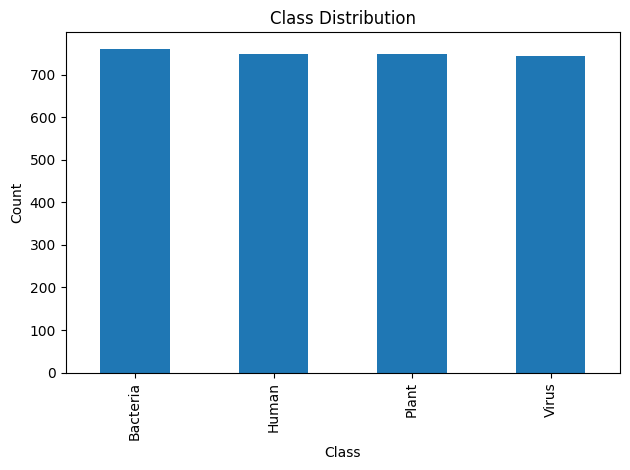

In [18]:
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

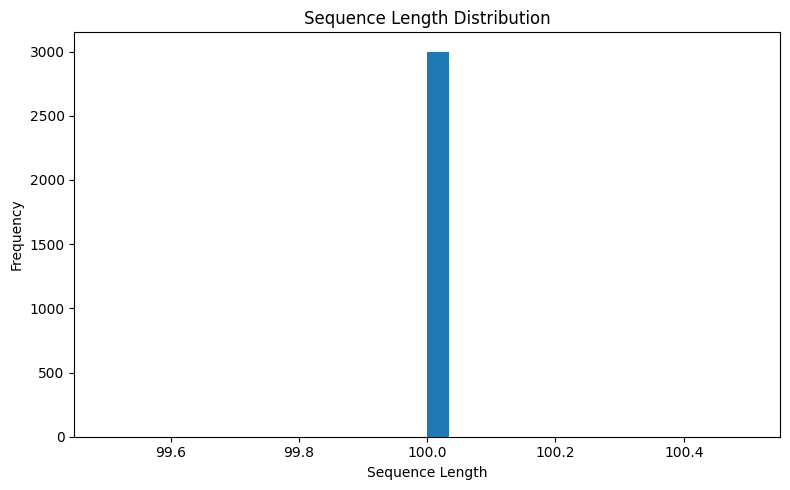

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df['seq_length'], bins=30)
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

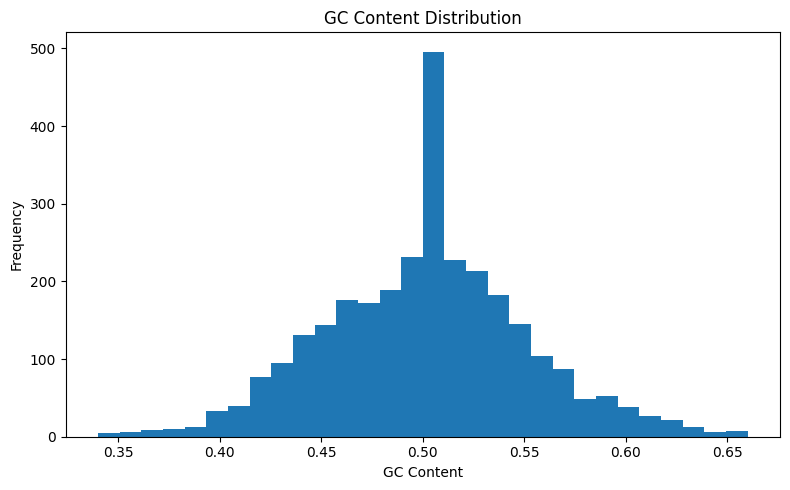

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df['GC_content'], bins=30)
plt.title("GC Content Distribution")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [21]:
avg_len = df.groupby('class')['seq_length'].mean()
print(avg_len)

class
Bacteria    100.0
Human       100.0
Plant       100.0
Virus       100.0
Name: seq_length, dtype: float64


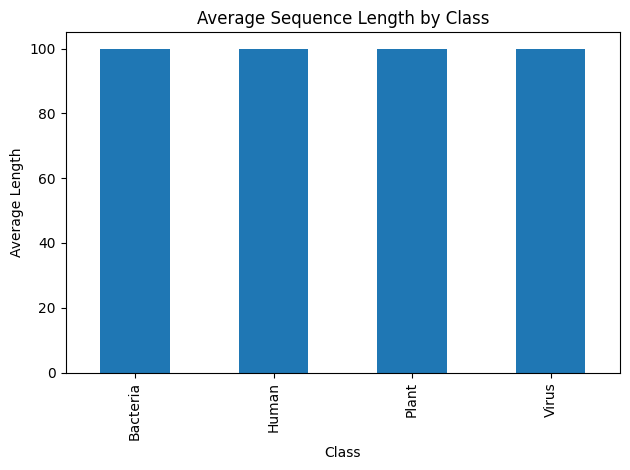

In [22]:
avg_len.plot(kind='bar')
plt.title("Average Sequence Length by Class")
plt.xlabel("Class")
plt.ylabel("Average Length")
plt.tight_layout()
plt.show()

In [23]:
def get_kmers(sequence, k=4):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

In [24]:
df['kmers'] = df['sequence'].apply(lambda x: ' '.join(get_kmers(x, k=4)))

In [25]:
print(df[['sequence', 'kmers', 'class']].head())

                                            sequence  \
0  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...   
1  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...   
2  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...   
3  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...   
4  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...   

                                               kmers     class  
0  CTTT TTTC TTCG TCGG CGGG GGGA GGAT GATA ATAC T...  Bacteria  
1  TTGA TGAC GACC ACCA CCAA CAAA AAAT AATT ATTT T...     Virus  
2  GCGT CGTG GTGA TGAG GAGT AGTT GTTC TTCT TCTA C...  Bacteria  
3  ACTA CTAC TACG ACGC CGCG GCGG CGGA GGAC GACA A...     Human  
4  TTCA TCAA CAAT AATG ATGC TGCA GCAG CAGA AGAT G...     Human  


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
vectorizer = TfidfVectorizer(max_features=1500)
X = vectorizer.fit_transform(df['kmers'])
y = df['class']

In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 256)
y shape: (3000,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.24833333333333332


In [32]:
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.265


In [33]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.21833333333333332


In [34]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)
print("Linear SVM Accuracy:", svm_acc)

Linear SVM Accuracy: 0.26166666666666666


In [35]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Linear SVM'],
    'Accuracy': [nb_acc, lr_acc, dt_acc, svm_acc]
})

print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
1  Logistic Regression  0.265000
3           Linear SVM  0.261667
0          Naive Bayes  0.248333
2        Decision Tree  0.218333


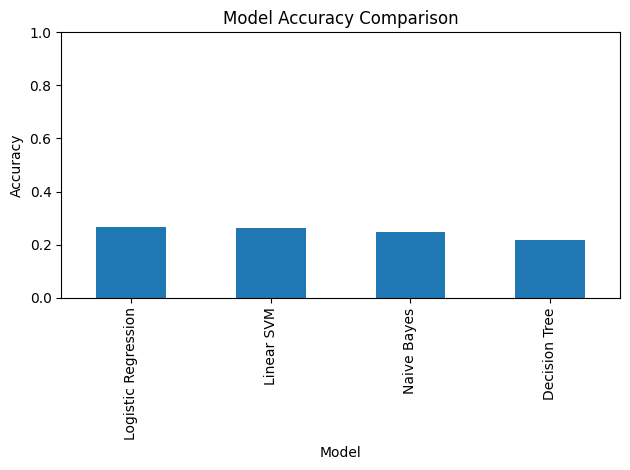

In [36]:
results.sort_values(by='Accuracy', ascending=False).plot(
    x='Model', y='Accuracy', kind='bar', legend=False
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [37]:
final_model = lr_model

In [38]:
final_model = svm_model

[[42 41 31 38]
 [39 34 35 42]
 [35 33 40 41]
 [31 38 39 41]]


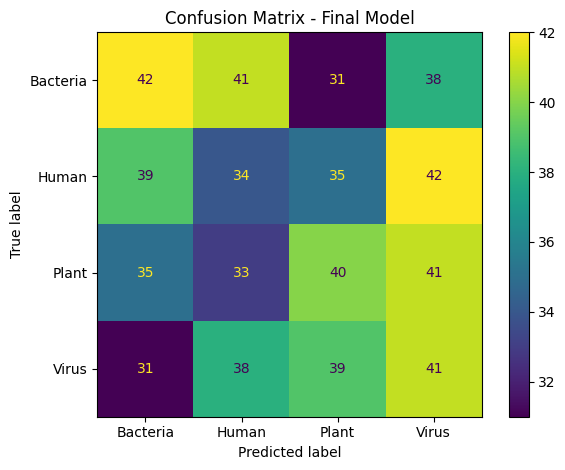

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_final = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.show()

In [40]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

    Bacteria       0.29      0.28      0.28       152
       Human       0.23      0.23      0.23       150
       Plant       0.28      0.27      0.27       149
       Virus       0.25      0.28      0.26       149

    accuracy                           0.26       600
   macro avg       0.26      0.26      0.26       600
weighted avg       0.26      0.26      0.26       600



In [41]:
!pip install ipywidgets

In [42]:
import ipywidgets as widgets
from IPython.display import display
import re

In [43]:
# Input box
input_box = widgets.Text(
    placeholder='Enter DNA sequence here',
    description='DNA:',
    layout=widgets.Layout(width='500px')
)

# Button
button = widgets.Button(description="Predict")

# Output area
output = widgets.Output()

display(input_box, button, output)

Text(value='', description='DNA:', layout=Layout(width='500px'), placeholder='Enter DNA sequence here')

Button(description='Predict', style=ButtonStyle())

Output()

In [44]:
final_model = lr_model

In [45]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)

final_model = lr_model

In [46]:
vectorizer = TfidfVectorizer(max_features=1500)
X = vectorizer.fit_transform(df['kmers'])
y = df['class']

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
vectorizer = TfidfVectorizer(max_features=1500)
X = vectorizer.fit_transform(df['kmers'])
y = df['class']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)

final_model = lr_model

In [51]:
print(X.shape)
print(X_train.shape)

(3000, 256)
(2400, 256)


In [52]:
from sklearn.metrics import accuracy_score

y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.265


In [53]:
import ipywidgets as widgets
from IPython.display import display
import re

In [54]:
dna_input = widgets.Text(
    placeholder='Enter DNA sequence',
    description='DNA:',
    layout=widgets.Layout(width='500px')
)

predict_button = widgets.Button(description='Predict')
result_label = widgets.Label(value='')

display(dna_input, predict_button, result_label)

Text(value='', description='DNA:', layout=Layout(width='500px'), placeholder='Enter DNA sequence')

Button(description='Predict', style=ButtonStyle())

Label(value='')

In [57]:
def predict_dna_fast(b):
    user_seq = dna_input.value.strip().upper()
    user_seq = re.sub(r'[^ATGC]', '', user_seq)

    if len(user_seq) < 10:
        result_label.value = "Sequence too short."
        return

    user_kmers = ' '.join(get_kmers(user_seq, k=4))
    user_vector = vectorizer.transform([user_kmers])
    prediction = final_model.predict(user_vector)

    result_label.value = f"Predicted Class: {prediction[0]}"

In [59]:
print(df['class'].value_counts())

class
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64


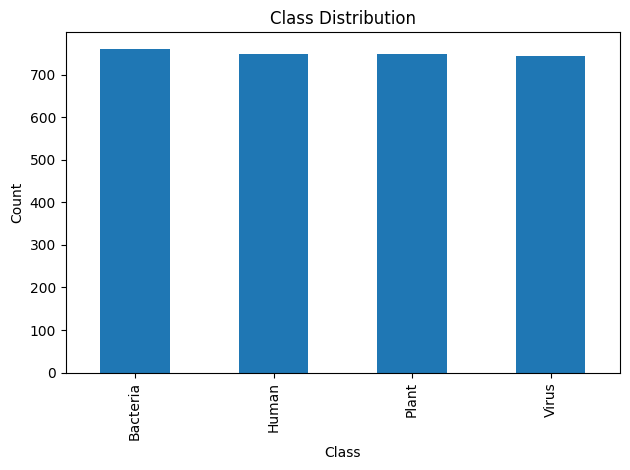

In [60]:
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [61]:
def get_kmers(sequence, k=4):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

df['kmers'] = df['sequence'].apply(lambda x: ' '.join(get_kmers(x, k=4)))

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['kmers'])
y = df['class']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.25333333333333335

Confusion Matrix:
 [[35 41 35 41]
 [34 38 35 43]
 [33 38 45 33]
 [33 46 36 34]]

Classification Report:
               precision    recall  f1-score   support

    Bacteria       0.26      0.23      0.24       152
       Human       0.23      0.25      0.24       150
       Plant       0.30      0.30      0.30       149
       Virus       0.23      0.23      0.23       149

    accuracy                           0.25       600
   macro avg       0.25      0.25      0.25       600
weighted avg       0.25      0.25      0.25       600



In [67]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.26166666666666666

Confusion Matrix:
 [[39 42 29 42]
 [43 41 29 37]
 [36 40 43 30]
 [36 41 38 34]]

Classification Report:
               precision    recall  f1-score   support

    Bacteria       0.25      0.26      0.25       152
       Human       0.25      0.27      0.26       150
       Plant       0.31      0.29      0.30       149
       Virus       0.24      0.23      0.23       149

    accuracy                           0.26       600
   macro avg       0.26      0.26      0.26       600
weighted avg       0.26      0.26      0.26       600



In [69]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.24

Confusion Matrix:
 [[37 42 39 34]
 [32 39 38 41]
 [43 32 40 34]
 [41 44 36 28]]

Classification Report:
               precision    recall  f1-score   support

    Bacteria       0.24      0.24      0.24       152
       Human       0.25      0.26      0.25       150
       Plant       0.26      0.27      0.26       149
       Virus       0.20      0.19      0.20       149

    accuracy                           0.24       600
   macro avg       0.24      0.24      0.24       600
weighted avg       0.24      0.24      0.24       600



In [70]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
1          Naive Bayes  0.261667
0  Logistic Regression  0.253333
2           Linear SVM  0.240000


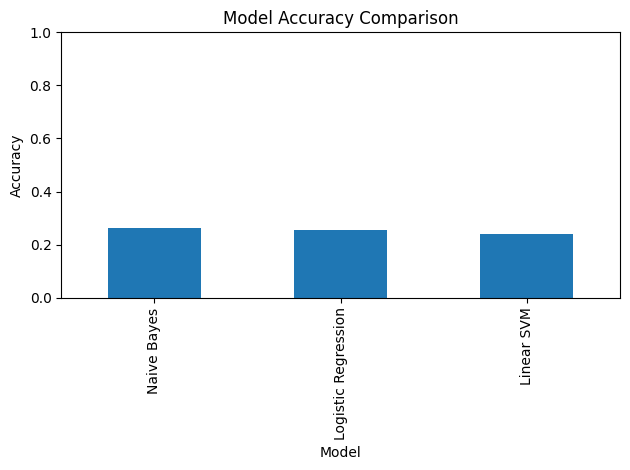

In [71]:
results.sort_values(by='Accuracy', ascending=False).plot(
    x='Model', y='Accuracy', kind='bar', legend=False
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [72]:
final_model = lr_model

In [73]:
final_model = svm_model

In [74]:
final_model = nb_model

In [75]:
human_sample = df[df['class'] == 'Human'].iloc[0]['sequence']

human_kmers = ' '.join(get_kmers(human_sample, k=4))
human_vector = vectorizer.transform([human_kmers])

prediction = final_model.predict(human_vector)

print("Predicted Class:", prediction[0])

Predicted Class: Human


In [76]:
import ipywidgets as widgets
from IPython.display import display

In [77]:
dna_input = widgets.Text(
    placeholder='Enter DNA sequence',
    description='DNA:',
    layout=widgets.Layout(width='500px')
)

predict_button = widgets.Button(description='Predict')
result_label = widgets.Label(value='')

display(dna_input, predict_button, result_label)

Text(value='', description='DNA:', layout=Layout(width='500px'), placeholder='Enter DNA sequence')

Button(description='Predict', style=ButtonStyle())

Label(value='')

In [78]:
predict_button.on_click(predict_dna_fast)